In [1]:
import numpy as np
import matplotlib.pyplot as plt
import RF_Track as rft
from scipy.optimize import minimize, curve_fit
from CLEAR_line import *
from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from RF_track_utils import *
from flatness import *


RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
def supergaussian1D(x, A, x0, sigma_x, P):
    return A * np.exp(-( (x-x0)**2 /(2*sigma_x**2) )**P)
    
def r90(sig,P):
    return sig * np.sqrt(2) * (-np.log(0.9))**(1/(2*P))

#80% of central beam
def mask80(x):
    cdf = np.cumsum(x, dtype=float)
    cdf /= cdf[-1] # Normalize CDF to 1
    mask = (cdf >= 0.1) & (cdf <= 0.9) # Mask for central 80%
    return x[mask]

def moving_average(x):
    n = int(len(x)/10)
    """Simple moving average with window size n."""
    return np.convolve(x, np.ones(n)/n, mode='same')
            
def sum_2gaussians(x, A, x0, sigma_x):
    return A * (np.exp(-( (x-x0)**2 /(2*sigma_x**2) )) + np.exp(-( (x+x0)**2 /(2*sigma_x**2) )) )

def flatness(x):
    
    x = moving_average(x) #smoothing
    x = mask80(x)
    return (max(x)-min(x))/ (max(x)+min(x))

def plot_phsp(T,M, n_bins=50,fov=200,title=''):
     
    def scatter_hist(x, y, ax, ax_histx, ax_histy):
        
        ax_histx.tick_params(axis="x", labelbottom=True)
        ax_histy.tick_params(axis="y", labelleft=True)

        # the scatter plot:
        ax.scatter(x, y,s=1,alpha=0.5)
        ax.set_xlim(-fov,fov)
        ax.set_ylim(-fov,fov)

        ax.set_xlabel('X (mm)')  # Set x-axis label for scatter plot
        ax.set_ylabel('Y (mm)')

        slice_width = 1
        phsp_xslice = M[(M[:,2] < slice_width)]
        phsp_xslice = phsp_xslice[(phsp_xslice[:,2] > -slice_width)]
        
        phsp_yslice = M[(M[:,0] < slice_width)]
        phsp_yslice = phsp_yslice[(phsp_yslice[:,0] > -slice_width)]

        
        hist_x, bin_edges_x = np.histogram(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov])
        bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2


        hist_y, bin_edges_y = np.histogram(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov])
        bin_centers_y = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2

        #fits
        p0=[np.max(hist_x),  np.mean(phsp_xslice[:,0]), np.std(phsp_xslice[:,0]), 4]
        params_x, _ = curve_fit(supergaussian1D, bin_centers_x, hist_x, p0=p0)

        params_y, _ = curve_fit(supergaussian1D, bin_centers_y, hist_y, p0=p0)
        xy_fit_curve = np.linspace(-fov, fov, 500)
       
        sig_x,sig_y, P_x, P_y = params_x[2], params_y[2], params_x[3], params_y[3]
        r90_x, r90_y = r90(sig_x, P_x), r90(sig_y, P_y)
    
        # Plot SuperGaussian fits

        ax_histx.hist(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov], color="b",alpha=0.6,label= ' X-Intensity')
        ax_histx.plot(xy_fit_curve, supergaussian1D(xy_fit_curve, *params_x), 'r-', label=f"SuperGaussian Fit (P={params_x[3]:.2f},r90={r90_x:.2f})")
        ax_histx.plot(bin_centers_x, moving_average(hist_x), 'k-', label=f'Smoothed (F={flatness(hist_x):.3f})')
        ax_histx.legend()


        

        ax_histy.hist(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov], color="b",alpha=0.6,label= ' Y-Intensity',orientation="horizontal")
        ax_histy.plot(supergaussian1D(xy_fit_curve, *params_y), xy_fit_curve,  'r-', label=f"SuperGaussian Fit (P={params_y[3]:.2f},r90={r90_x:.2f})")
        ax_histy.plot(moving_average(hist_y),bin_centers_y, 'k-', label=f'Smoothed (F={flatness(hist_y):.3f})')
        ax_histy.legend()

    fig, axs = plt.subplot_mosaic([['histx', '.'],
                                ['scatter', 'histy']],
                                figsize=(10, 8),
                                width_ratios=(4, 1), height_ratios=(1, 4),
                                layout='constrained')
    fig.suptitle(title)
    scatter_hist(M[:,0], M[:,2], axs['scatter'], axs['histx'], axs['histy'])
    plt.show()


from sklearn.neighbors import NearestNeighbors

def nearest_neighbor_test(x,y):
    points = np.array([x,y]).T
    nbrs = NearestNeighbors(n_neighbors=2).fit(points)
    distances, _ = nbrs.kneighbors(points)
    nn_distances = distances[:, 1]  # skip self-distance

    mean_dist = nn_distances.mean()
    std_dist = nn_distances.std()
    print(nn_distances)
    cv = std_dist / mean_dist  
    # coefficient of variation = 0.52 is poisson uniform, <0.52 is too uniform, >0.52 clustering

    return mean_dist, std_dist, cv

def mask2d(x,y):
    r = np.sqrt(x**2 + y**2)
    threshold = np.percentile(r, 60)
    mask = r <= threshold
    return x[mask],y[mask]

In [3]:

mass = RF_Track.electronmass    # particle mass in MeV/c^2
population = 10 * RF_Track.nC               # number of particles per bunch                         # particle charge in e units
P_ref = 198  
N_particles = int(500000)
charge = -1


            # reference bunch



In [4]:
DSF_lattice = rft.Lattice()
DSF_lattice.append(rft.Drift(0.1))
S1 = rft.Absorber(0.0001,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(0.0001,'air')
S1.disable_energy_straggling()
S1.set_shape ('circular', 1,1  )
DSF_lattice.append(S1)
DSF_lattice.append(rft.Drift(0.532)) #end of s1 to s2

# #smaller one: 
s2_radii = [1.4 , 1.05, 0.7 , 0.35]
s2_thickness = [0.08719553, 0.18061171, 0.26891643, 0.26327633]
for i in range(len(s2_thickness)):
    Slice = rft.Absorber(s2_thickness[i]/1000,31.9, 37, 288.31,1.32,-1)
    Slice.disable_energy_straggling()
    Slice.set_shape ('circular',  abs(s2_radii[i])/1000,abs(s2_radii[i])/1000 )
    DSF_lattice.append(Slice)

DSF_lattice.append(rft.Drift(2.024)) 

In [5]:
best_seen = [np.inf, None]
def loss_twiss (twiss_params,lattice,target_beamsize=5):
    beta, alpha = twiss_params
    Twiss = RF_Track.Bunch6d_twiss()
    Twiss.beta_x = beta        # m
    Twiss.beta_y = beta   # m
    Twiss.alpha_x = alpha
    Twiss.alpha_y = alpha
    Twiss.emitt_x = 17.3     # mm.mrad normalised emittance
    Twiss.emitt_y = 25.2    # mm.mrad normalised emittance

    B0 = RF_Track.Bunch6d_QR(mass, population, charge, P_ref, Twiss, 100000)             # reference bunch

    B1 = lattice.track(B0)
    I = B1.get_info()
    sx, sy, ax, ay= I.sigma_x, I.sigma_y, I.alpha_x, I.alpha_y
    # T = lattice.get_transport_table(
    # '%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
 
    # masked_x, masked_y = mask2d(M[:,0],M[:,2])
    # print('max x,y:', max(masked_x), max(masked_y))
    # print('nn contribution:', nearest_neighbor_test(masked_x,masked_y)[2])
    # loss = nearest_neighbor_test(masked_x,masked_y)[2] + 0.5 * abs(masked_x.max()/target_size-1) + 0.5 * abs(masked_y.max()/target_size-1)
    loss = merit_beam_Uniform(B1,target_beamsize,0.3)
    if loss < best_seen[0]:
        best_seen[0] = loss
        best_seen[1] = twiss_params
    print('loss:', loss,'twiss =',twiss_params )
    return loss

In [ ]:

  
rng = np.random.default_rng()
opt_losses, opt_params = [],[]
best_seen = [np.inf, None]
for i in range(10):
  x0 = np.append(rng.uniform(low=0, high=30, size=1), rng.uniform(low=-2, high=2, size=1))
  res = minimize(loss_twiss,
                        x0=x0, args=(DSF_lattice),
                        bounds=[ (0,40 ),(-4,4) ], 
                        method='Powell',
                        options={'disp': True
                                , 'xtol':0.01}
                      #   tol=1e-2
                        )
  
  opt_losses.append(res.fun)
  opt_params.append(res.x)

i = np.argmin(opt_losses)
print(f"opt_loss={opt_losses[i]:.3f}, params={opt_params[i]}")
print(f'best_seen={best_seen}')

41493 100000
189.12765164355685 0.0 0 5
loss: 189.12765164355685 twiss = [23.94577604  1.49640317]
39383 100000
97.51978485811648 0.0 0 5
loss: 97.51978485811648 twiss = [15.27864045  1.49640317]
41564 100000
195.819542709616 0.0 0 5
loss: 195.819542709616 twiss = [24.72135955  1.49640317]
35926 100000
29.779388720766224 0.0 0 5
loss: 29.779388720766224 twiss = [9.4427191  1.49640317]
33063 100000
11.2272685650893 0.0 0 5
loss: 11.2272685650893 twiss = [5.83592135 1.49640317]
30743 100000
13.35426910741671 0.0 0 5
loss: 13.35426910741671 twiss = [3.88225666 1.49640317]
32867 100000
7.0700237586946155 0.0 0 5
loss: 7.0700237586946155 twiss = [5.34476287 1.49640317]
32117 100000
4.419266209557111 0.0 0 5
loss: 4.419266209557111 twiss = [4.94242848 1.49640317]
31672 100000
20.26100921082685 0.0 0 5
loss: 20.26100921082685 twiss = [4.53747888 1.49640317]
31987 100000
3.7085489696555007 0.0 0 5
loss: 3.7085489696555007 twiss = [4.78775149 1.49640317]
32096 100000
7.713073801739285 0.0 0 5
l

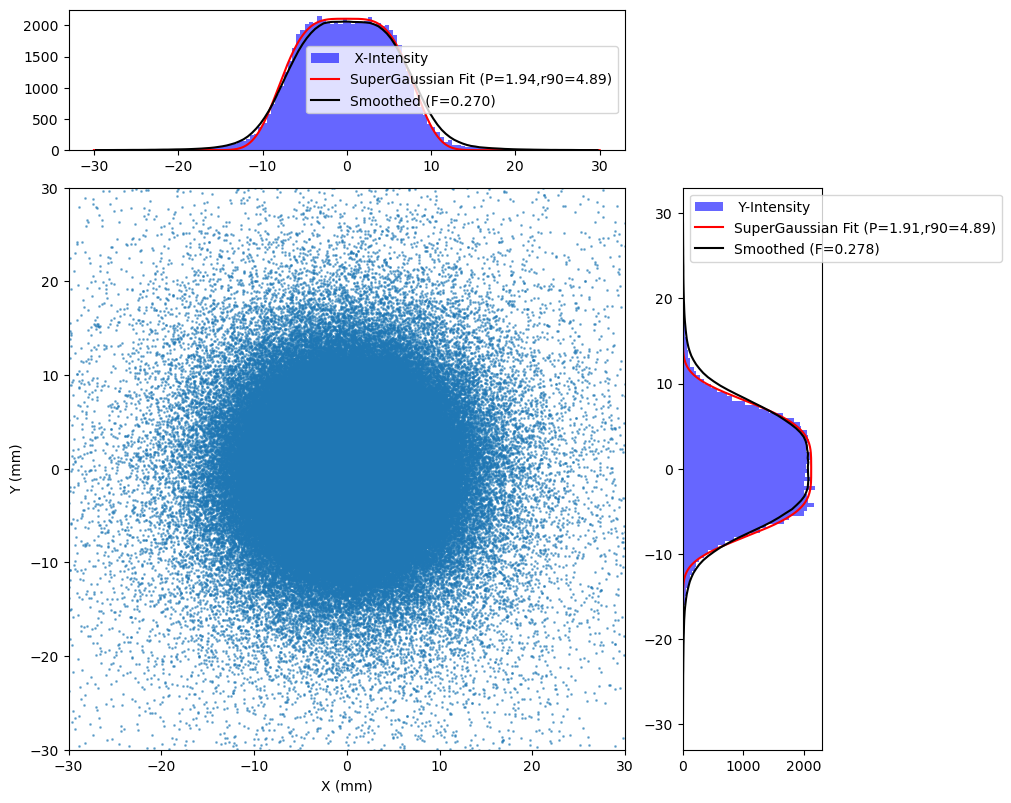

2

In [7]:
beta, alpha = 5.3,0.9
Twiss = RF_Track.Bunch6d_twiss()
Twiss.beta_x = beta        # m
Twiss.beta_y = beta   # m
Twiss.alpha_x = alpha
Twiss.alpha_y = alpha
Twiss.emitt_x = 20     # mm.mrad normalised emittance
Twiss.emitt_y = 20 
B0_1 = RF_Track.Bunch6d_QR(mass, population, charge, P_ref, Twiss, N_particles)             # reference bunch
B1 = DSF_lattice.track(B0_1)
T = DSF_lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')
masked_x, masked_y = mask2d(M[:,0],M[:,2])
plot_phsp(T,M,120,30)


1000000
1000
2

checking results

**TOPAS**


In [12]:
beta_gamma = P_ref / mass
Twiss = RF_Track.Bunch6d_twiss()
Twiss.alpha_x = 0.9
Twiss.alpha_y = 0.9

Twiss.beta_x = 4
Twiss.beta_y = 4

Twiss.emitt_x = 17.3   # mm.mrad normalised emittance
Twiss.emitt_y = 25.2     # mm.mrad


Twiss.emitt_x = 12.8   # mm.mrad normalised emittance
Twiss.emitt_y = 20     # mm.mrad

Twiss.emitt_x = 17.3   # mm.mrad normalised emittance
Twiss.emitt_y = 25     # mm.mrad

sig_x = 0.5
sig_y = 0.5
sig_x = np.sqrt(Twiss.emitt_x * Twiss.beta_x / beta_gamma)
sig_y = np.sqrt(Twiss.emitt_y * Twiss.beta_y / beta_gamma)
sig_xp =  np.sqrt(Twiss.emitt_x * (1 + Twiss.alpha_x**2) / Twiss.beta_x / beta_gamma)
sig_yp =  np.sqrt(Twiss.emitt_y * (1 + Twiss.alpha_y**2) / Twiss.beta_y / beta_gamma)
# sig_xp = 1.5
# sig_yp = 1.5
print('sig_x:', sig_x, 'sig_y:', sig_y, 'sig_xp:', sig_xp, 'sig_yp:', sig_yp)

sig_x: 0.4226009373182012 sig_y: 0.5080160211821845 sig_xp: 0.14213785331550105 sig_yp: 0.17086641397188362


In [ ]:
#topas

output_filename='CLEAR_redesign_DSF'
dose_depth=5 #holders are 1.1cm downstream of tank window
dir = '/Users/sabrinawang/Desktop/DPhil_Project/'
profile = "dose"
RFT_name = 'CLEAR_840'



s1_l, s2_width, s2_depth =  0.1, 1.4,0.8

setup = partrec_gaussian_optimiser_utils(world_material="Vacuum")

setup.generate_phsp_beam(sig_x,sig_y,sig_xp,sig_yp,P_ref,0,300000)

s1_pos = 0.001
setup.add_flat_scatterer(s1_l,"Aluminum",s1_pos)



s2_radii = [1.4 , 1.05, 0.7 , 0.35]
s2_thickness = [0.08719553, 0.18061171, 0.26891643, 0.26327633]

for i in range(len(s2_thickness)):
    sname = 'S2_slice_'+str(i)
    slice_position = s1_pos + s1_l + 532 + sum(s2_thickness[:i-1]) #532 is distance from s1 end to s2 start
    setup.add_cylinder(sname, s2_thickness[i-1],0, s2_radii[i-1], 'Peek', slice_position)



setup.add_cylinder('kapton_holder',0.025, 0,33,"kapton",s1_pos+532+s1_l+sum(s2_thickness)) #check position


setup.add_cylinder("window",0.075,0,500,"kapton",s1_pos+532+s1_l+sum(s2_thickness)+1524) #check position
setup.add_cylinder('tank_window',0.1, 0,100,"kapton",s1_pos+532+s1_l+sum(s2_thickness)+2024) #this somehow blurs out the ring outside not sure why



if profile == "dose":
    setup.add_tank_bins(s1_pos+532+s1_l+sum(s2_thickness)+2025, dose_depth, 100,100,1,output_filename,width=30)
elif profile == "intensity":
    setup.add_patient(s1_pos+532+s1_l+sum(s2_thickness)+2025)

setup.run_topas(view_setup=False)


Welcome to TOPAS, Tool for Particle Simulation (Version 3.9)
Loading parameters starting from: /Users/sabrinawang/Desktop/DPhil_Project/topas_main.txt

Geant4 Data directory has been specified by the
TOPAS_G4_DATA_DIR environment variable as /Applications/G4Data

**************************************************************
 Geant4 version Name: geant4-10-07-patch-03 [MT]   (19-November-2021)
  << in Multi-threaded mode >> 
                       Copyright : Geant4 Collaboration
                      References : NIM A 506 (2003), 250-303
                                 : IEEE-TNS 53 (2006), 270-278
                                 : NIM A 835 (2016), 186-225
                             WWW : http://geant4.org/
**************************************************************

TOPAS is in MT mode, setting number of threads to: 6

TOPAS set the tolerances based on the World size to:
      Surface tolerance = 0.05 nm, and radial tolerance = 0.05 nm.
/opt/anaconda3/envs/RFT_topas_bdsim/s

66.7


/Users/sabrinawang/Desktop/DPhil_Project/topasToDose.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


10
(100, 100)
(100,)
(100,)
(100, 100)
[-14.85 -14.55 -14.25 -13.95 -13.65 -13.35 -13.05 -12.75 -12.45 -12.15
 -11.85 -11.55 -11.25 -10.95 -10.65 -10.35 -10.05  -9.75  -9.45  -9.15
  -8.85  -8.55  -8.25  -7.95  -7.65  -7.35  -7.05  -6.75  -6.45  -6.15
  -5.85  -5.55  -5.25  -4.95  -4.65  -4.35  -4.05  -3.75  -3.45  -3.15
  -2.85  -2.55  -2.25  -1.95  -1.65  -1.35  -1.05  -0.75  -0.45  -0.15
   0.15   0.45   0.75   1.05   1.35   1.65   1.95   2.25   2.55   2.85
   3.15   3.45   3.75   4.05   4.35   4.65   4.95   5.25   5.55   5.85
   6.15   6.45   6.75   7.05   7.35   7.65   7.95   8.25   8.55   8.85
   9.15   9.45   9.75  10.05  10.35  10.65  10.95  11.25  11.55  11.85
  12.15  12.45  12.75  13.05  13.35  13.65  13.95  14.25  14.55  14.85]


/Users/sabrinawang/Desktop/DPhil_Project/uniformity_fit.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


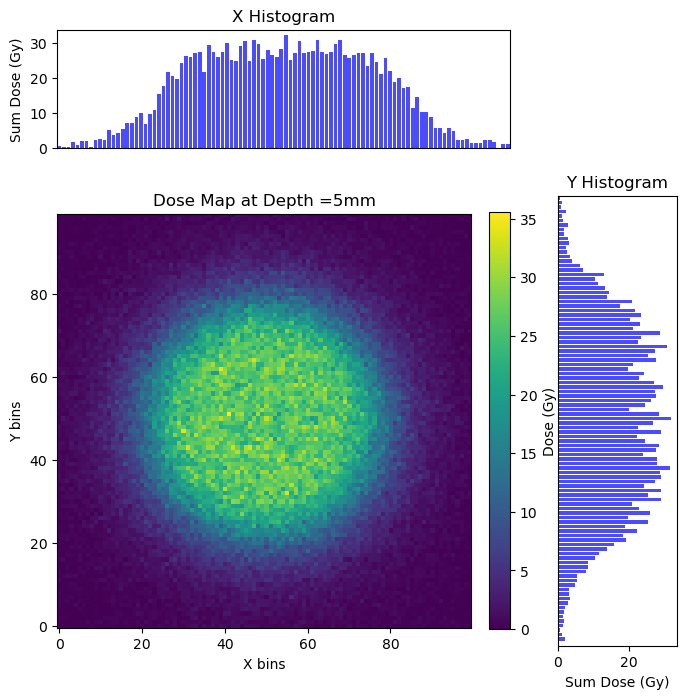

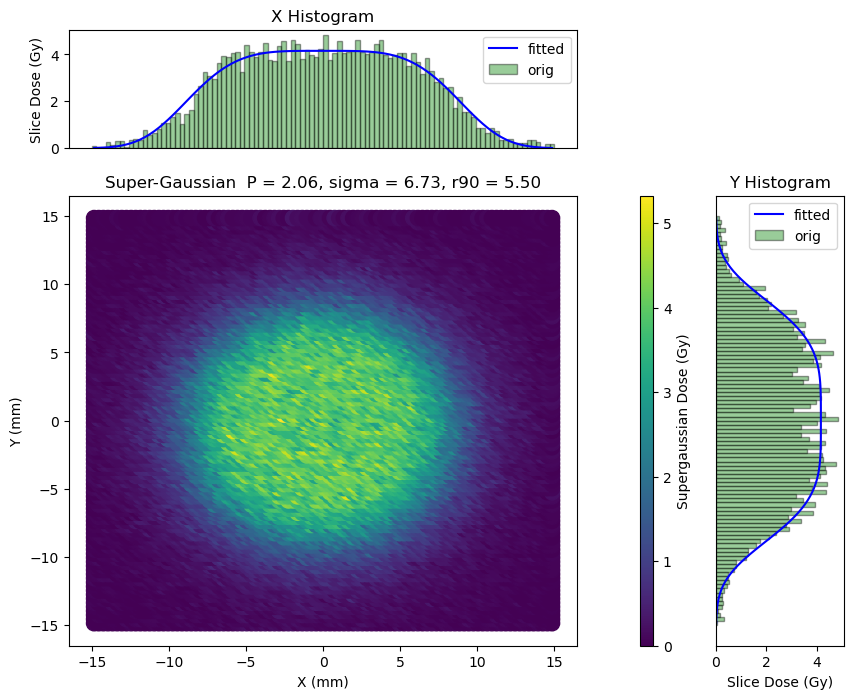

In [11]:

if profile == "dose":
#             # initialise plotting class
    doseMap = getDosemap("DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv",N_particles, dose_depth, output_filename, plot = True) 
    fitDoseMap(N_particles, dose_depth,output_filename)

elif profile == "intensity":
    plotter = partrec_foil_plotting('patient_beam.phsp' ) #filename defined inside partrec_gaussian_optimiser_utils
    # plot transverse distributions and energy spectrum at patient
    plotter.show_transverse_beam(output_filename, s1_l, s2_depth, s2_width,particle= 'e',fov= 25, col=10)
    plotter.show_transverse_beam(output_filename, s1_l, s2_depth, s2_width,particle= 'y',fov=25, col=10)

In [ ]:


#FLASH single bunch this year from May 11
Twiss.beta_x = 47.8        # m
Twiss.beta_y = 27.7     # m
Twiss.alpha_x = -5.36
Twiss.alpha_y = -4.72
Twiss.emitt_x = 17.3     # mm.mrad normalised emittance
Twiss.emitt_y = 25.2     # mm.mrad
# Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# Twiss.sigma_pt = 10     # permille
Twiss.mean_xp = 0.0
Twiss.mean_yp = 0.0

B0 = RF_Track.Bunch6d_QR(mass, population, charge, P_ref, Twiss, 10000)    
# quad_currents = np.array([19.4, 20.9, 2, 30, 33, 0, 57, 61, 8, 0, 0]) # k1 values from OPTIMISE_CLEAR.py, last two quads not in selection
quad_currents = np.array([11,32,22,19,32,18,0,0,0,0,0]) 
start = 'CA.QFD0350' #'CA.ACS0270S_MECH'
end = 'CA.DHJ0840' #'CA.STLINE$END'
best_seen = [np.inf, None]

def match_quads(last_triplet_k1s, target_beta, target_alpha):
    CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start, end, P_ref, quad_currents) 
    Q = CLEAR_lattice.get_quadrupoles()
    for i in [6,7,8]:
        Q[i].set_strength(last_triplet_k1s[i-6])
        
    
    CLEAR_lattice.append(rft.Drift(0.084))
    B1 = CLEAR_lattice.track(B0)
    I = B1.get_info()
    loss = 2* abs(I.beta_x - target_beta) + 2* abs(I.beta_y - target_beta) + abs(I.alpha_x - target_alpha) + abs(I.alpha_y - target_alpha)
    print('loss:', loss,'k1s =',last_triplet_k1s, "beta, alpha:", I.beta_x,I.beta_y, I.alpha_x, I.alpha_y)
    if loss < best_seen[0]:
        best_seen[0] = loss
        best_seen[1] = last_triplet_k1s
    return loss

 

In [ ]:
best_seen = [np.inf, None]
rng = np.random.default_rng()
opt_loss = np.inf
# best_seen = [np.inf, None]
for i in range(5):
    x0 = rng.uniform(low=0, high=700, size=3) * [1,-1,1] 
    res = minimize(match_quads,
                            x0=x0, args=(4.8, 1.5),
                            bounds=[ (0,700 ), (-700,0 ), (0,700 ) ], #highest can be 772 apparently
                            method='Powell',
                            options={'disp': True
                                    , 'xtol':0.01}
                        #   tol=1e-2
                            )
    if res.fun < opt_loss:
            opt_loss = res.fun
            opt_params = res.x